## Import Libraries

In [1]:
import openai
from openai import OpenAI
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import time
import re
import os
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from datetime import datetime

----
## Set OpenAI key and create client
----

In [2]:
load_dotenv()

api_key = os.environ.get('OPENAI_API_KEY')
if not api_key:
    raise EnvironmentError(
        "OPENAI_API_KEY not found. "
        "Set it in your .env file or as an environment variable."
    )

client = OpenAI()

----
## Cost & Token Tracker
----

Tracks tokens and cost per API call across both prompt modes.
All pricing is for GPT-4o (as of 2025):
- Input:  $2.50 / 1M tokens
- Output: $10.00 / 1M tokens

A CostTracker instance is created per run (zero-shot / few-shot)
and passed into every API call so usage is recorded centrally.

In [3]:
# GPT-4o pricing (per token)
PRICE_INPUT_PER_TOKEN  = 2.50  / 1_000_000
PRICE_OUTPUT_PER_TOKEN = 10.00 / 1_000_000

class CostTracker:
    """
    Accumulates token usage and estimated cost across all API calls in a run.

    Each call_api() and generate_insight() call passes the tracker so every
    call's token usage is recorded. At the end of a run, summary() prints
    a breakdown by step and a total cost estimate.
    """

    def __init__(self, run_name):
        self.run_name = run_name
        self.calls = []   # list of dicts, one per API call

    def record(self, step, input_tokens, output_tokens):
        cost = (input_tokens  * PRICE_INPUT_PER_TOKEN +
                output_tokens * PRICE_OUTPUT_PER_TOKEN)
        self.calls.append({
            'step':          step,
            'input_tokens':  input_tokens,
            'output_tokens': output_tokens,
            'cost_usd':      cost
        })

    def total_cost(self):
        return sum(c['cost_usd'] for c in self.calls)

    def total_tokens(self):
        return {
            'input':  sum(c['input_tokens']  for c in self.calls),
            'output': sum(c['output_tokens'] for c in self.calls)
        }

    def summary(self):
        df = pd.DataFrame(self.calls)
        print(f"\n===== COST & TOKEN SUMMARY — {self.run_name} =====")
        print(f"Total API calls : {len(self.calls)}")
        print(f"Total input tokens  : {self.total_tokens()['input']:,}")
        print(f"Total output tokens : {self.total_tokens()['output']:,}")
        print(f"Total estimated cost: ${self.total_cost():.4f}")
        print()
        print("Breakdown by step:")
        breakdown = df.groupby('step').agg(
            calls        = ('cost_usd', 'count'),
            input_tokens = ('input_tokens', 'sum'),
            output_tokens= ('output_tokens','sum'),
            cost_usd     = ('cost_usd', 'sum')
        )
        breakdown['cost_usd'] = breakdown['cost_usd'].map('${:.4f}'.format)
        print(breakdown.to_string())
        print()

    def to_dict(self):
        """Return summary as dict for comparison table."""
        t = self.total_tokens()
        return {
            'run_name':      self.run_name,
            'total_calls':   len(self.calls),
            'input_tokens':  t['input'],
            'output_tokens': t['output'],
            'total_tokens':  t['input'] + t['output'],
            'cost_usd':      round(self.total_cost(), 4)
        }

----
## Load and Preprocess Data
----

Same 100-row balanced sample used for both runs
so comparisons are fair (same texts, same labels).

In [4]:
def load_data(file_name, limit=100):
    """
    Load and return a balanced sample of limit rows (50 Human, 50 AI).
    random_state=42 ensures the same rows are used across both runs.
    """
    df = pd.read_csv(file_name)
    df['label'] = df['generated'].map({0: 'Human', 1: 'AI'})

    samples_per_class = limit // 2
    human_sample = df[df['label'] == 'Human'].sample(samples_per_class, random_state=42)
    ai_sample    = df[df['label'] == 'AI'].sample(samples_per_class, random_state=42)

    balanced_df = pd.concat([human_sample, ai_sample]).sample(frac=1, random_state=42)
    print(f"Loaded {len(balanced_df)} rows ({samples_per_class} Human, {samples_per_class} AI)")
    return balanced_df

df = load_data('AI_Human.csv')

Loaded 100 rows (50 Human, 50 AI)


----
## Few-Shot Examples
----

Three carefully chosen examples covering the hardest cases:

1. Structured human writing — formal tone but correctly labelled Human (low confidence)
2. AI text with deliberate errors — typos mimic humans but correctly labelled AI (high confidence)
3. Genuine borderline — moderate confidence, shows the model what 50-65 should look like

Easy cases (obvious AI boilerplate, clearly informal human) are deliberately excluded,
they teach the model nothing it doesn't already know.

In [5]:
FEW_SHOT_EXAMPLES = [
    {
        "text": "The implementation of renewable energy subsidies has demonstrated measurable "
                "impact across multiple economic sectors. According to the International Energy "
                "Agency, wind and solar capacity additions reached record levels in 2023. "
                "Policymakers must therefore consider the long-term fiscal implications of "
                "sustaining such incentive programmes, particularly in the context of competing "
                "budgetary priorities.",
        "label": "Human",
        "confidence": 25,
        "evidence_human": [
            "References a specific external source (IEA), which reflects genuine research behaviour.",
            "The phrase 'policymakers must therefore consider' shows an author taking a position — "
            "AI tends to present options rather than advocate.",
            "'Particularly in the context of' is a hedging construction more natural in human "
            "academic writing than AI output."
        ],
        "evidence_ai": [
            "Formal, structured tone with no stylistic quirks could suggest AI generation.",
            "Logical paragraph structure (observation → statistic → implication) is common in AI."
        ],
        "reasoning": "Despite the formal tone, the specific citation and opinionated framing "
                     "indicate human authorship. Formal human writing often resembles AI superficially. "
                     "Confidence is low (25) because the text is genuinely structured, but the "
                     "source reference and advocacy tip the balance toward Human."
    },
    {
        "text": "In my opinion the goverment should do more about climate. "
                "There are many reasons y this is importent. First of all the "
                "temperature is rising evry year and this is a big problim. "
                "I think we should use more solar panles and wind turbins because "
                "they are cleaner than coal witch is bad for the enviroment.",
        "label": "AI",
        "confidence": 80,
        "evidence_human": [
            "Multiple spelling errors (goverment, importent, evry, problim) resemble genuine typos.",
            "Casual phrasing ('In my opinion', 'I think') sounds like informal human writing."
        ],
        "evidence_ai": [
            "Despite the errors, the argument follows a perfectly structured pattern: "
            "claim → reason → evidence → conclusion. Humans writing this casually would "
            "not maintain such logical coherence.",
            "The typos are consistent in type (vowel omission, phonetic spelling) but "
            "distributed too evenly — genuine human typos cluster around specific words, "
            "not spread uniformly.",
            "No sentence fragments, no self-corrections, no tangents — all signs of "
            "AI-generated text mimicking informal writing."
        ],
        "reasoning": "This is a deliberately misleading text — surface errors mimic human "
                     "informality but the underlying structure is too coherent for genuinely "
                     "casual writing. The pattern of errors (phonetic, uniform) is an AI "
                     "fingerprint. Confidence is high (80) despite the surface noise."
    },
    {
        "text": "Social media has changed how we communicate, for better and worse. "
                "On one hand, it connects people across distances and amplifies marginalised "
                "voices. On the other hand, it can spread misinformation and create echo chambers. "
                "The key is finding balance — using these platforms mindfully while being aware "
                "of their limitations.",
        "label": "AI",
        "confidence": 65,
        "evidence_human": [
            "The em-dash in 'The key is finding balance — using' feels like a deliberate "
            "stylistic choice, slightly more natural than AI punctuation.",
            "'For better and worse' is a common but slightly idiomatic phrase."
        ],
        "evidence_ai": [
            "Classic 'on one hand / on the other hand' structure is a strong AI signal — "
            "models default to this balanced framing.",
            "The conclusion ('The key is finding balance') is a generic wrap-up typical "
            "of AI-generated essays that must end positively.",
            "No personal anecdote, no specific example, no genuine opinion — purely abstract."
        ],
        "reasoning": "This is a genuine borderline case — moderate confidence (65). The balanced "
                     "structure and generic conclusion are AI signals, but the em-dash and idiomatic "
                     "phrase create genuine ambiguity. A score near 50 would be wrong here — "
                     "the structural evidence outweighs the surface stylistic signals."
    }
]

def build_few_shot_block():
    """
    Formats the few-shot examples into a prompt string.
    Each example shows the full reasoning chain so the model
    learns what good evidence and calibrated confidence looks like.
    """
    block = "Here are examples of how to analyse texts correctly:\n\n"
    for i, ex in enumerate(FEW_SHOT_EXAMPLES, 1):
        human_ev = '\n'.join(f'- {e}' for e in ex['evidence_human'])
        ai_ev    = '\n'.join(f'- {e}' for e in ex['evidence_ai'])
        block += f"""--- Example {i} ---
Text: {ex['text']}

Evidence for human:
{human_ev}

Evidence for AI:
{ai_ev}

Reasoning: {ex['reasoning']}

Confidence: {ex['confidence']}
Verdict: {ex['label']}

"""
    block += "--- Now analyse the following text using the same approach ---\n"
    return block

print("Few-shot block preview (first 500 chars):")
print(build_few_shot_block()[:500], "...")

Few-shot block preview (first 500 chars):
Here are examples of how to analyse texts correctly:

--- Example 1 ---
Text: The implementation of renewable energy subsidies has demonstrated measurable impact across multiple economic sectors. According to the International Energy Agency, wind and solar capacity additions reached record levels in 2023. Policymakers must therefore consider the long-term fiscal implications of sustaining such incentive programmes, particularly in the context of competing budgetary priorities.

Evidence for huma ...


----
## STEP 1 — Classification (supports both prompt modes)
----

call_api() now accepts a prompt_mode argument: 'zero_shot' or 'few_shot'.
In few_shot mode, the three examples are prepended to the task instruction.
Everything else (format, parsing, caching) is identical between modes.

Token usage is recorded via the CostTracker passed in.

In [6]:
def call_api(text, client, tracker, model="gpt-4o", prompt_mode="zero_shot"):
    """
    CHAIN STEP 1: Classify text as Human or AI.

    Args:
        text:        Text to classify
        client:      OpenAI client instance
        tracker:     CostTracker — records tokens and cost for this call
        model:       OpenAI model string
        prompt_mode: 'zero_shot' or 'few_shot'

    Returns:
        tuple: (verdict, confidence_score, response_content)
    """
    task_instruction = """Analyze whether this text was written by a human or AI.

You must commit to a clear verdict. Do not hedge. Use the full 0-100 confidence
scale — scores near 50 should only appear when evidence is genuinely balanced.
Most texts will show clear signals in one direction.

Text: {text}

First, list specific evidence that suggests human authorship.
Second, list specific evidence that suggests AI authorship.
Third, provide a confidence score from 0-100 (where 0 is definitely human, 100 is definitely AI).
Finally, provide your verdict: 'Human' or 'AI'.

Format your answer exactly like this:
Evidence for human:
- point 1
- point 2

Evidence for AI:
- point 1
- point 2

Confidence: [0-100]

Verdict: Human/AI"""

    # Prepend few-shot examples when in few_shot mode
    if prompt_mode == "few_shot":
        full_prompt = build_few_shot_block() + "\n" + task_instruction.format(text=text)
    else:
        full_prompt = task_instruction.format(text=text)

    messages = [
        {"role": "system", "content": "You are an expert at detecting AI-generated text."},
        {"role": "user",   "content": full_prompt}
    ]

    try:
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=0,
            max_tokens=400
        )

        # Record token usage in the tracker
        tracker.record(
            step='step1_classify',
            input_tokens=response.usage.prompt_tokens,
            output_tokens=response.usage.completion_tokens
        )

        result = response.choices[0].message.content

        confidence_match = re.search(r'Confidence:\s*(\d+)', result)
        confidence = int(confidence_match.group(1)) if confidence_match else 50

        verdict_match = re.search(r'Verdict:\s*(Human|AI)', result)
        verdict = verdict_match.group(1) if verdict_match else (
            "AI" if "AI" in result.split("\n")[-1] else "Human"
        )

        return verdict, confidence, result

    except Exception as e:
        print(f"Error in call_api: {e}")
        return "Error", 0, str(e)

----
## STEP 2 — Insight Chain
----

Unchanged from v2 — Step 2 always receives Step 1 output regardless of prompt mode.
Token usage is recorded via the tracker.

In [7]:
def generate_insight(verdict, confidence, step1_response, client, tracker, model="gpt-4o"):
    """
    CHAIN STEP 2: Generate structured insight from Step 1 output.

    Receives only the Step 1 classification output — does not re-read the original text.
    This is what makes it a genuine chain: two causally linked but independent LLM calls.

    Args:
        verdict, confidence, step1_response: outputs from call_api()
        client:  OpenAI client
        tracker: CostTracker — records tokens and cost for this call
        model:   OpenAI model string

    Returns:
        dict with keys: pattern_type, production_method, recommended_action,
                        insight_summary, raw_insight_response
    """
    confidence_label = (
        "very high" if confidence >= 80 else
        "moderate-to-high" if confidence >= 60 else
        "borderline" if confidence >= 40 else "low"
    )

    prompt = f"""You are an expert analyst reviewing the output of an AI text detection system.

A classification model has analysed a piece of text and produced the following assessment:

--- STEP 1 CLASSIFICATION OUTPUT ---
Verdict: {verdict}
Confidence: {confidence}/100 ({confidence_label} confidence)
Full evidence:
{step1_response}
--- END OF STEP 1 OUTPUT ---

Based ONLY on the evidence and verdict above (do not re-analyse the original text),
provide a structured insight in EXACTLY this format:

Pattern Type: [one of: Formulaic AI | Conversational AI | Hybrid | Authentic Human | Uncertain]
Production Method: [1-2 sentences on how this text was likely produced]
Recommended Action: [1 sentence on what a reviewer or academic should do with this text]
Insight Summary: [1 concise sentence summarising the key finding]"""

    messages = [
        {"role": "system", "content": "You are an expert at interpreting AI text detection results and generating actionable insights."},
        {"role": "user",   "content": prompt}
    ]

    try:
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=0,
            max_tokens=200
        )

        tracker.record(
            step='step2_insight',
            input_tokens=response.usage.prompt_tokens,
            output_tokens=response.usage.completion_tokens
        )

        result = response.choices[0].message.content

        def extract_field(label, text):
            match = re.search(rf"{label}:\s*(.+)", text)
            return match.group(1).strip() if match else "Not extracted"

        return {
            "pattern_type":       extract_field("Pattern Type",      result),
            "production_method":  extract_field("Production Method", result),
            "recommended_action": extract_field("Recommended Action",result),
            "insight_summary":    extract_field("Insight Summary",   result),
            "raw_insight_response": result
        }

    except Exception as e:
        print(f"Error in generate_insight: {e}")
        return {
            "pattern_type": "Error", "production_method": str(e),
            "recommended_action": "Error", "insight_summary": "Error",
            "raw_insight_response": str(e)
        }

----
## Chain Runner
----

Runs both steps for the full dataset.
prompt_mode ('zero_shot' or 'few_shot') controls which Step 1 prompt is used.
Each mode has its own cache files so results are stored independently
and reruns don't re-call the API for already-processed texts.

In [8]:
def classify_dataset(df, client, tracker, model="gpt-4o",
                     prompt_mode="zero_shot",
                     cache_file=None, insight_cache_file=None):
    """
    Run the full two-step chain over the dataset.

    Args:
        df:                DataFrame with 'text' and 'label' columns
        client:            OpenAI client
        tracker:           CostTracker for this run
        model:             OpenAI model string
        prompt_mode:       'zero_shot' or 'few_shot'
        cache_file:        JSON cache for Step 1 results
        insight_cache_file:JSON cache for Step 2 results

    Returns:
        DataFrame with classification + insight columns added
    """
    results_df = df.copy()

    # Load Step 1 cache
    cache = {}
    if cache_file and os.path.exists(cache_file):
        try:
            with open(cache_file, 'r') as f:
                cache = json.load(f)
            print(f"Loaded {len(cache)} cached Step 1 results ({prompt_mode})")
        except:
            print("Could not load Step 1 cache, starting fresh")

    # Load Step 2 cache
    insight_cache = {}
    if insight_cache_file and os.path.exists(insight_cache_file):
        try:
            with open(insight_cache_file, 'r') as f:
                insight_cache = json.load(f)
            print(f"Loaded {len(insight_cache)} cached Step 2 insights ({prompt_mode})")
        except:
            print("Could not load Step 2 cache, starting fresh")

    # Initialise output columns
    for col in ['predicted','confidence','api_response',
                'pattern_type','production_method',
                'recommended_action','insight_summary',
                'prompt_mode']:
        results_df[col] = None

    for idx, row in tqdm(results_df.iterrows(), total=len(results_df),
                         desc=f"Running chain [{prompt_mode}]"):
        unique_id = str(hash(row['text']))

        # --- STEP 1: Classify ---
        if unique_id in cache:
            verdict, confidence, response = cache[unique_id]
        else:
            verdict, confidence, response = call_api(
                row['text'], client, tracker,
                model=model, prompt_mode=prompt_mode
            )
            cache[unique_id] = (verdict, confidence, response)
            if cache_file and (len(cache) % 5 == 0):
                with open(cache_file, 'w') as f:
                    json.dump(cache, f)
            time.sleep(2)

        results_df.at[idx, 'predicted']    = verdict
        results_df.at[idx, 'confidence']   = confidence
        results_df.at[idx, 'api_response'] = response
        results_df.at[idx, 'prompt_mode']  = prompt_mode

        # --- STEP 2: Generate insight ---
        if verdict != "Error":
            if unique_id in insight_cache:
                insight = insight_cache[unique_id]
            else:
                insight = generate_insight(
                    verdict, confidence, response,
                    client, tracker, model=model
                )
                insight_cache[unique_id] = insight
                if insight_cache_file and (len(insight_cache) % 5 == 0):
                    with open(insight_cache_file, 'w') as f:
                        json.dump(insight_cache, f)
                time.sleep(2)

            results_df.at[idx, 'pattern_type']       = insight['pattern_type']
            results_df.at[idx, 'production_method']  = insight['production_method']
            results_df.at[idx, 'recommended_action'] = insight['recommended_action']
            results_df.at[idx, 'insight_summary']    = insight['insight_summary']

    # Final cache saves
    if cache_file:
        with open(cache_file, 'w') as f: json.dump(cache, f)
    if insight_cache_file:
        with open(insight_cache_file, 'w') as f: json.dump(insight_cache, f)

    return results_df

----
## Evaluation Function
----

In [9]:
def evaluate_results(results_df, run_name):
    """Evaluate classification results and return a metrics dict."""
    valid = results_df[results_df['predicted'] != 'Error'].copy()

    accuracy = accuracy_score(valid['label'], valid['predicted'])
    valid['ai_score']    = valid['confidence'] / 100.0
    valid['true_binary'] = (valid['label'] == 'AI').astype(int)
    roc_auc = roc_auc_score(valid['true_binary'], valid['ai_score'])

    report = classification_report(valid['label'], valid['predicted'], output_dict=True)
    cm     = confusion_matrix(valid['label'], valid['predicted'], labels=['Human', 'AI'])

    print(f"\n===== RESULTS — {run_name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"Valid samples: {len(valid)} | Errors: {len(results_df) - len(valid)}")
    print("\nClassification Report:")
    print(classification_report(valid['label'], valid['predicted']))

    return {
        'run_name':    run_name,
        'accuracy':    round(accuracy, 4),
        'roc_auc':     round(roc_auc, 4),
        'macro_f1':    round(report['macro avg']['f1-score'], 4),
        'ai_recall':   round(report['AI']['recall'], 4),
        'human_recall':round(report['Human']['recall'], 4),
        'ai_precision':round(report['AI']['precision'], 4),
        'conf_mean':   round(valid['confidence'].mean(), 1),
        'conf_std':    round(valid['confidence'].std(), 1),
        'conf_min':    int(valid['confidence'].min()),
        'conf_max':    int(valid['confidence'].max()),
        'cm':          cm
    }

----
## RUN A — Zero-Shot
----

Baseline run using the zero-shot chain-of-thought prompt.
Delete zero_shot_cache.json and zero_shot_insight_cache.json
before running if you want a clean run.

In [10]:
tracker_zs = CostTracker(run_name="zero_shot")

results_zs = classify_dataset(
    df, client, tracker_zs,
    prompt_mode="zero_shot",
    cache_file="zero_shot_cache.json",
    insight_cache_file="zero_shot_insight_cache.json"
)

metrics_zs = evaluate_results(results_zs, "Zero-Shot CoT")
tracker_zs.summary()

results_zs.to_csv("results_zero_shot.csv", index=False)
print("Saved: results_zero_shot.csv")

Running chain [zero_shot]: 100%|██████████| 100/100 [13:40<00:00,  8.20s/it]


===== RESULTS — Zero-Shot CoT =====
Accuracy : 0.7600
ROC-AUC  : 0.8324
Valid samples: 100 | Errors: 0

Classification Report:
              precision    recall  f1-score   support

          AI       0.71      0.88      0.79        50
       Human       0.84      0.64      0.73        50

    accuracy                           0.76       100
   macro avg       0.78      0.76      0.76       100
weighted avg       0.78      0.76      0.76       100


===== COST & TOKEN SUMMARY — zero_shot =====
Total API calls : 200
Total input tokens  : 96,583
Total output tokens : 23,740
Total estimated cost: $0.4789

Breakdown by step:
                calls  input_tokens  output_tokens cost_usd
step                                                       
step1_classify    100         62815          14619  $0.3032
step2_insight     100         33768           9121  $0.1756

Saved: results_zero_shot.csv


----
## RUN B — Few-Shot CoT
----

Same dataset, same chain structure, same model.
Only difference: three labelled examples prepended to the Step 1 prompt.
Delete few_shot_cache.json and few_shot_insight_cache.json
before running if you want a clean run.

In [11]:
tracker_fs = CostTracker(run_name="few_shot")

results_fs = classify_dataset(
    df, client, tracker_fs,
    prompt_mode="few_shot",
    cache_file="few_shot_cache.json",
    insight_cache_file="few_shot_insight_cache.json"
)

metrics_fs = evaluate_results(results_fs, "Few-Shot CoT")
tracker_fs.summary()

results_fs.to_csv("results_few_shot.csv", index=False)
print("Saved: results_few_shot.csv")

Running chain [few_shot]: 100%|██████████| 100/100 [12:12<00:00,  7.33s/it]


===== RESULTS — Few-Shot CoT =====
Accuracy : 0.7000
ROC-AUC  : 0.7608
Valid samples: 100 | Errors: 0

Classification Report:
              precision    recall  f1-score   support

          AI       0.64      0.94      0.76        50
       Human       0.88      0.46      0.61        50

    accuracy                           0.70       100
   macro avg       0.76      0.70      0.68       100
weighted avg       0.76      0.70      0.68       100


===== COST & TOKEN SUMMARY — few_shot =====
Total API calls : 200
Total input tokens  : 177,496
Total output tokens : 23,922
Total estimated cost: $0.6830

Breakdown by step:
                calls  input_tokens  output_tokens cost_usd
step                                                       
step1_classify    100        143315          14950  $0.5078
step2_insight     100         34181           8972  $0.1752

Saved: results_few_shot.csv


----
## Comparison Report — Performance + Cost
----

Side-by-side comparison of both runs across all metrics,
plus the token and cost delta between prompt modes.
This is the key output for your report and CV.

In [12]:
def comparison_report(metrics_zs, metrics_fs, tracker_zs, tracker_fs):
    """
    Print a side-by-side performance and cost comparison.
    Highlights deltas so it's immediately clear what few-shot adds.
    """
    cost_zs = tracker_zs.to_dict()
    cost_fs = tracker_fs.to_dict()

    print("=" * 62)
    print(f"{'METRIC':<28} {'ZERO-SHOT':>10} {'FEW-SHOT':>10} {'DELTA':>10}")
    print("=" * 62)

    perf_rows = [
        ("Accuracy",      metrics_zs['accuracy'],     metrics_fs['accuracy']),
        ("ROC-AUC",       metrics_zs['roc_auc'],      metrics_fs['roc_auc']),
        ("Macro F1",       metrics_zs['macro_f1'],     metrics_fs['macro_f1']),
        ("AI recall",      metrics_zs['ai_recall'],    metrics_fs['ai_recall']),
        ("Human recall",   metrics_zs['human_recall'], metrics_fs['human_recall']),
        ("AI precision",   metrics_zs['ai_precision'], metrics_fs['ai_precision']),
        ("Conf. mean",     metrics_zs['conf_mean'],    metrics_fs['conf_mean']),
        ("Conf. std",      metrics_zs['conf_std'],     metrics_fs['conf_std']),
    ]

    print("\n--- Performance ---")
    for label, zs_val, fs_val in perf_rows:
        delta = fs_val - zs_val
        sign  = '+' if delta >= 0 else ''
        print(f"{label:<28} {zs_val:>10.4f} {fs_val:>10.4f} {sign+f'{delta:.4f}':>10}")

    print("\n--- Cost & Tokens ---")
    cost_rows = [
        ("Total API calls",   cost_zs['total_calls'],   cost_fs['total_calls'],   False),
        ("Input tokens",      cost_zs['input_tokens'],  cost_fs['input_tokens'],  False),
        ("Output tokens",     cost_zs['output_tokens'], cost_fs['output_tokens'], False),
        ("Total tokens",      cost_zs['total_tokens'],  cost_fs['total_tokens'],  False),
        ("Estimated cost ($)",cost_zs['cost_usd'],      cost_fs['cost_usd'],      True),
    ]

    for label, zs_val, fs_val, is_cost in cost_rows:
        delta = fs_val - zs_val
        sign  = '+' if delta >= 0 else ''
        if is_cost:
            print(f"{label:<28} {'$'+str(zs_val):>10} {'$'+str(fs_val):>10} {sign+'$'+f'{abs(delta):.4f}':>10}")
        else:
            print(f"{label:<28} {zs_val:>10,} {fs_val:>10,} {sign+str(delta):>10}")

    print("=" * 62)

    # Cost per percentage point of accuracy gained
    acc_delta  = metrics_fs['accuracy'] - metrics_zs['accuracy']
    cost_delta = cost_fs['cost_usd']    - cost_zs['cost_usd']
    if acc_delta > 0:
        cpp = cost_delta / acc_delta
        print(f"\nCost per +1pp accuracy gain: ${cpp:.4f}")
    else:
        print("\nNo accuracy gain from few-shot — zero-shot is the better choice on cost grounds.")

comparison_report(metrics_zs, metrics_fs, tracker_zs, tracker_fs)

METRIC                        ZERO-SHOT   FEW-SHOT      DELTA

--- Performance ---
Accuracy                         0.7600     0.7000    -0.0600
ROC-AUC                          0.8324     0.7608    -0.0716
Macro F1                         0.7565     0.6817    -0.0748
AI recall                        0.8800     0.9400    +0.0600
Human recall                     0.6400     0.4600    -0.1800
AI precision                     0.7097     0.6351    -0.0746
Conf. mean                      61.7000    64.7000    +3.0000
Conf. std                       24.3000    15.9000    -8.4000

--- Cost & Tokens ---
Total API calls                     200        200         +0
Input tokens                     96,583    177,496     +80913
Output tokens                    23,740     23,922       +182
Total tokens                    120,323    201,418     +81095
Estimated cost ($)              $0.4789     $0.683   +$0.2041

No accuracy gain from few-shot — zero-shot is the better choice on cost grounds.


----
## Visualisations — Side-by-Side Plots
----

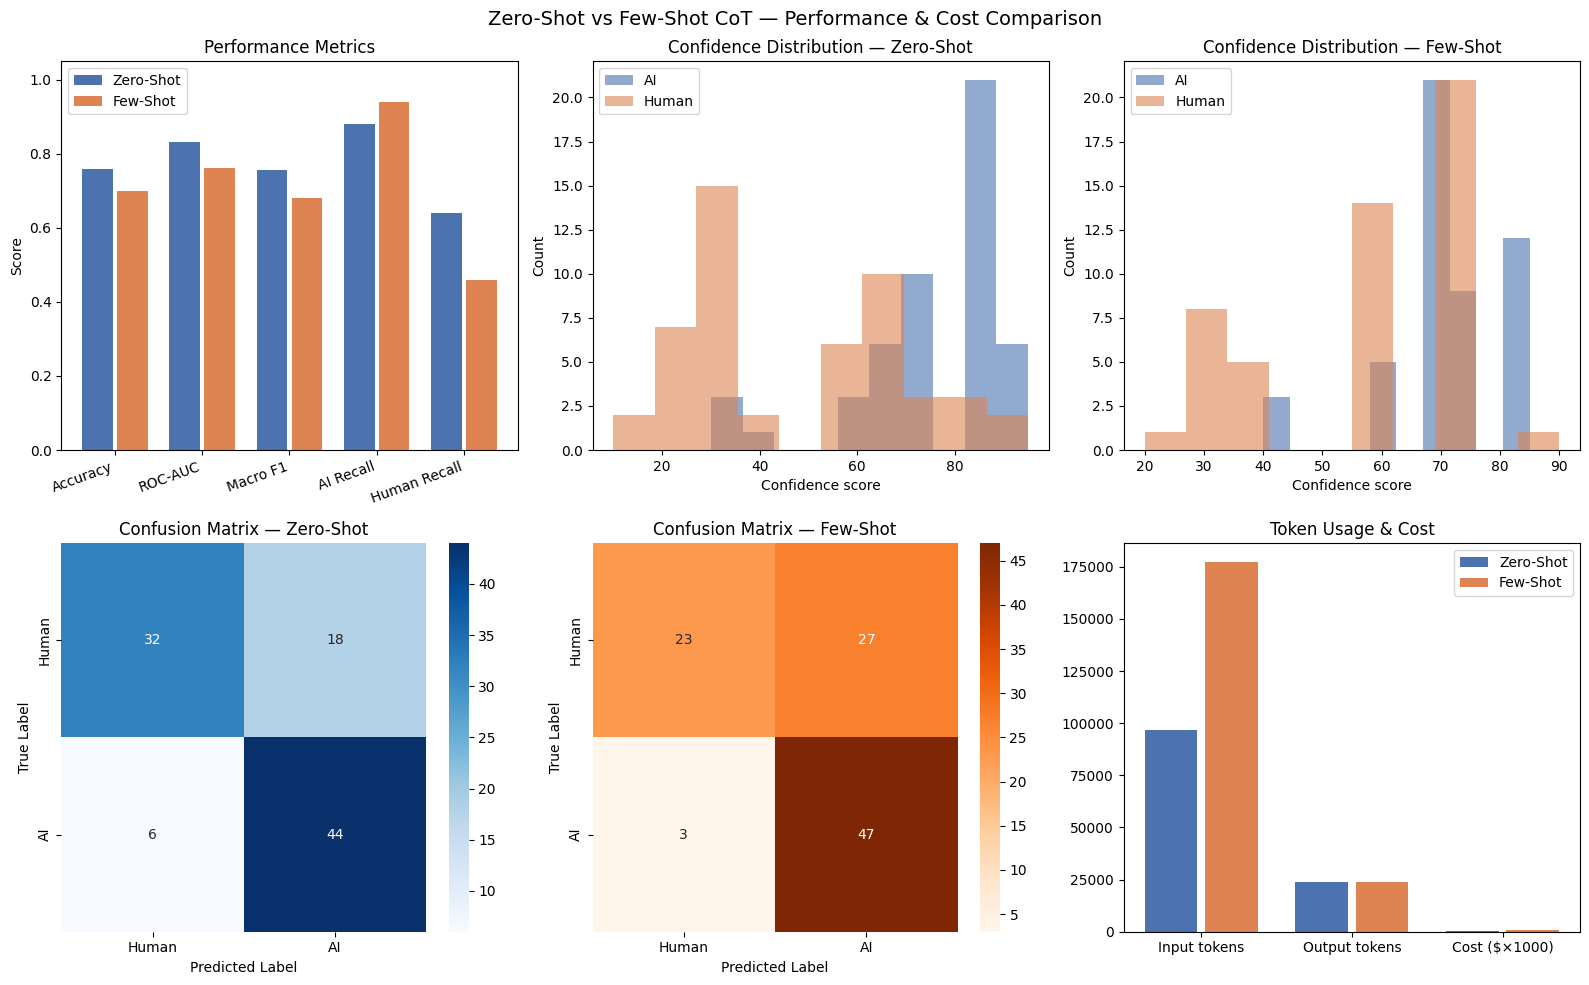

Saved: comparison_results.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Zero-Shot vs Few-Shot CoT — Performance & Cost Comparison', fontsize=14)

# 1. Performance bar chart
ax = axes[0, 0]
perf_labels = ['Accuracy', 'ROC-AUC', 'Macro F1', 'AI Recall', 'Human Recall']
zs_vals = [metrics_zs['accuracy'], metrics_zs['roc_auc'], metrics_zs['macro_f1'],
           metrics_zs['ai_recall'], metrics_zs['human_recall']]
fs_vals = [metrics_fs['accuracy'], metrics_fs['roc_auc'], metrics_fs['macro_f1'],
           metrics_fs['ai_recall'], metrics_fs['human_recall']]
x = range(len(perf_labels))
ax.bar([i - 0.2 for i in x], zs_vals, width=0.35, label='Zero-Shot', color='#4C72B0')
ax.bar([i + 0.2 for i in x], fs_vals, width=0.35, label='Few-Shot',  color='#DD8452')
ax.set_xticks(list(x))
ax.set_xticklabels(perf_labels, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Performance Metrics')
ax.legend()
ax.set_ylabel('Score')

# 2. Confidence distribution — zero-shot
ax = axes[0, 1]
for label, color in [('AI', '#4C72B0'), ('Human', '#DD8452')]:
    subset = results_zs[results_zs['label'] == label]['confidence']
    ax.hist(subset, bins=10, alpha=0.6, label=label, color=color)
ax.set_title('Confidence Distribution — Zero-Shot')
ax.set_xlabel('Confidence score')
ax.set_ylabel('Count')
ax.legend()

# 3. Confidence distribution — few-shot
ax = axes[0, 2]
for label, color in [('AI', '#4C72B0'), ('Human', '#DD8452')]:
    subset = results_fs[results_fs['label'] == label]['confidence']
    ax.hist(subset, bins=10, alpha=0.6, label=label, color=color)
ax.set_title('Confidence Distribution — Few-Shot')
ax.set_xlabel('Confidence score')
ax.set_ylabel('Count')
ax.legend()

# 4. Confusion matrix — zero-shot
ax = axes[1, 0]
sns.heatmap(metrics_zs['cm'], annot=True, fmt='d', ax=ax,
            xticklabels=['Human','AI'], yticklabels=['Human','AI'], cmap='Blues')
ax.set_title('Confusion Matrix — Zero-Shot')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# 5. Confusion matrix — few-shot
ax = axes[1, 1]
sns.heatmap(metrics_fs['cm'], annot=True, fmt='d', ax=ax,
            xticklabels=['Human','AI'], yticklabels=['Human','AI'], cmap='Oranges')
ax.set_title('Confusion Matrix — Few-Shot')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

# 6. Token & cost comparison
ax = axes[1, 2]
cost_labels = ['Input tokens', 'Output tokens', 'Cost ($×1000)']
zs_cost = tracker_zs.to_dict()
fs_cost = tracker_fs.to_dict()
zs_cost_vals = [zs_cost['input_tokens'], zs_cost['output_tokens'], zs_cost['cost_usd'] * 1000]
fs_cost_vals = [fs_cost['input_tokens'], fs_cost['output_tokens'], fs_cost['cost_usd'] * 1000]
x2 = range(len(cost_labels))
ax.bar([i - 0.2 for i in x2], zs_cost_vals, width=0.35, label='Zero-Shot', color='#4C72B0')
ax.bar([i + 0.2 for i in x2], fs_cost_vals, width=0.35, label='Few-Shot',  color='#DD8452')
ax.set_xticks(list(x2))
ax.set_xticklabels(cost_labels)
ax.set_title('Token Usage & Cost')
ax.legend()

plt.tight_layout()
plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_results.png")

----
## Validate chain outputs — 5 sample texts showing both runs
----

For each sampled text, prints Step 1 and Step 2 output
from BOTH the zero-shot and few-shot runs side by side.
Useful for qualitative inspection of where the two runs differ.

In [14]:
# Load both Step 1 caches
with open("zero_shot_cache.json", "r") as f:
    cache_zs = json.load(f)
with open("few_shot_cache.json", "r") as f:
    cache_fs = json.load(f)

# Sample 5 rows — use same rows for both runs
sample_rows = results_zs.sample(5, random_state=77)

for _, row in sample_rows.iterrows():
    uid = str(hash(row['text']))
    zs  = cache_zs.get(uid, ("N/A", 0, "Not found"))
    fs  = cache_fs.get(uid, ("N/A", 0, "Not found"))

    row_fs = results_fs[results_fs['text'] == row['text']].iloc[0]

    print("=" * 70)
    print(f"True Label : {row['label']}")
    print()
    print(f"ZERO-SHOT  →  Verdict: {zs[0]}  |  Confidence: {zs[1]}/100")
    print(f"              Pattern: {row['pattern_type']}")
    print(f"              Insight: {row['insight_summary']}")
    print()
    print(f"FEW-SHOT   →  Verdict: {fs[0]}  |  Confidence: {fs[1]}/100")
    print(f"              Pattern: {row_fs['pattern_type']}")
    print(f"              Insight: {row_fs['insight_summary']}")
    print()

True Label : Human

ZERO-SHOT  →  Verdict: Human  |  Confidence: 60/100
              Pattern: Hybrid
              Insight: The text exhibits characteristics of both human and AI writing, with human errors and AI-like structure.

FEW-SHOT   →  Verdict: AI  |  Confidence: 75/100
              Pattern: Hybrid
              Insight: The text exhibits characteristics of both AI and human authorship, suggesting a collaborative or hybrid production process.

True Label : AI

ZERO-SHOT  →  Verdict: AI  |  Confidence: 75/100
              Pattern: Hybrid
              Insight: The text exhibits characteristics of both AI and human authorship, leading to a moderate-to-high confidence classification as AI-generated.

FEW-SHOT   →  Verdict: AI  |  Confidence: 85/100
              Pattern: Formulaic AI
              Insight: The text exhibits characteristics typical of AI-generated content, with a structured format and repetitive phrasing.

True Label : Human

ZERO-SHOT  →  Verdict: AI  |  Confid

----
## Validate chain outputs — 5 sample texts (zero-shot)
----

Zero-shot CoT outperformed few-shot across all primary metrics
(accuracy 0.76 vs 0.70, ROC-AUC 0.83 vs 0.76), so validation
uses the zero-shot results as the final system output.

For each sample, prints the full Step 1 evidence and
the Step 2 insight generated from it.

In [15]:
# Load zero-shot Step 1 cache for full evidence text
with open("zero_shot_cache.json", "r") as f:
    cache_zs = json.load(f)

# Sample 5 rows from zero-shot results
sample_rows = results_zs.sample(5, random_state=77)

for _, row in sample_rows.iterrows():
    uid = str(hash(row['text']))
    verdict, confidence, step1_response = cache_zs.get(
        uid, ("N/A", 0, "Not found in cache")
    )

    # Extract evidence sections from Step 1 response
    evidence_human_match = re.search(
        r"Evidence for [Hh]uman:\s*(.*?)\s*Evidence for AI:",
        step1_response, re.DOTALL
    )
    evidence_ai_match = re.search(
        r"Evidence for AI:\s*(.*?)\s*Confidence:",
        step1_response, re.DOTALL
    )
    evidence_human = evidence_human_match.group(1).strip() if evidence_human_match else "No evidence found."
    evidence_ai    = evidence_ai_match.group(1).strip()    if evidence_ai_match    else "No evidence found."

    print("=" * 60)
    print(f"True Label    : {row['label']}")
    print()
    print("--- STEP 1: Classification ---")
    print(f"Verdict       : {verdict}")
    print(f"Confidence    : {confidence}/100")
    print(f"Human Evidence: {evidence_human}")
    print(f"AI Evidence   : {evidence_ai}")
    print()
    print("--- STEP 2: Insight (generated from Step 1 output) ---")
    print(f"Pattern Type      : {row['pattern_type']}")
    print(f"Production Method : {row['production_method']}")
    print(f"Recommended Action: {row['recommended_action']}")
    print(f"Insight Summary   : {row['insight_summary']}")
    print()

True Label    : Human

--- STEP 1: Classification ---
Verdict       : Human
Confidence    : 60/100
Human Evidence: - The text contains numerous typographical errors and inconsistencies, such as "or" instead of "our," "BBT" instead of "but," and "OBT" instead of "out," which are more indicative of human typing errors rather than AI-generated text.
- The structure and flow of the text are somewhat disorganized, with abrupt topic shifts and a lack of coherence, which is more typical of human writing without editing.
AI Evidence   : - The text attempts to present structured arguments and includes references to articles and statistics, which are common in AI-generated content designed to mimic informative writing.
- Despite the errors, the text maintains a level of formality and attempts to use varied sentence structures, which can be characteristic of AI-generated text.

--- STEP 2: Insight (generated from Step 1 output) ---
Pattern Type      : Hybrid
Production Method : This text likely r